# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER , Victor LOUX | Hoang-Triet NGUYEN

## 1. Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données
*   C'est quoi le dataset ?

Ce dataset a été créé en récupérant des données sur Steam et sur Steam Games Scraper, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

Voici toutes les features que nous avons en disposition : appid,  name , release_date , required_age, price, dlc_count, metacritic_score, achievements, recommendations, categories, positive, negative, median_playtime_forever, peak_ccu, pct_pos_total

### Notre objectives
Trouver un jeu qui nous plaira en utilisant des techniques de clustering non supervisé. 


## 2. Importation des librairies et du dataset

In [237]:
# Importation des librairies
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import time
import numpy as np
from sklearn import cluster, metrics
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import Normalizer
# from sklearn import cluster
from sklearn.cluster import DBSCAN



df = pd.read_csv("./dataset/Steam_Games_2025.csv")
df.head()


,appid,name,release_date,required_age,price,dlc_count,metacritic_score,achievements,recommendations,categories,positive,negative,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,0,1,4401572,"['Multi-player', 'Cross-Platform Multiplayer',...",7480813,1135108,5174,1212356,86,8632939
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,0,37,1732007,"['Multi-player', 'PvP', 'Online PvP', 'Stats',...",1487960,1024436,0,616738,59,2513842
2,570,Dota 2,2013-07-09,0,0.00,2,90,0,14337,"['Multi-player', 'Co-op', 'Steam Trading Cards...",1998462,451338,898,555977,81,2452595
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,96,77,1803063,"['Single-player', 'Multi-player', 'PvP', 'Onli...",1719950,250012,7101,117698,87,1803832
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,0,0,1165929,"['Single-player', 'Multi-player', 'PvP', 'Onli...",1152763,218446,2434,89916,84,1168020


## 3. Prétraitement des données
Avant de travailler sur les données, il est important de ne garder que les features pertinentes et transformer certaines d'entre elles pour faciliter l'analyse.
### Nettoyage des données
Nous allons supprimer les collonnes suivantes :
- appid : identifiant unique du jeu, pas pertinent pour le clustering
- positive et negative : redondant avec pct_pos_total
- median_playtime_forever : données manquantes pour de nombreux jeux, pas pertinent pour le clustering

Pour limiter la taille du dataset et accélérer les calculs, seules les 3000 entrées avec le plus haut metacritic_score sont conservées. Cal garanti que nous ne perdrons pas du temps à analyser des jeux de mauvaise qualité.

In [238]:
## Supprimer du dataset
df = df.drop(columns=['appid', 'positive', 'negative', 'median_playtime_forever'])

## Garder que 3000 jeux avec le plus de metacritic_score et sort par 'metacritic_score' décroissant
df = df.nlargest(3000, 'metacritic_score').sort_values(by='metacritic_score', ascending=False)

## Remettre l'index après le filtrage
df = df.reset_index(drop=True)

### Transformation des données

In [239]:

## Transformer 'release_date' en Année de sortie et changer le nom de la colonne
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.rename(columns={'release_date': 'release_year'})

## Extraire 'single_player' et 'multi_player' de la colonne 'categories'
def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])

# Verifier les modifications
# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])

df.head()


Number of samples: 3000
Number of features: 13


,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
0,Disco Elysium - The Final Cut,2019,0,39.99,2,97,45,98796,1727,93,98950,1,0
1,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,117698,87,1803832,1,1
2,Baldur's Gate 3,2023,17,59.99,2,96,54,647659,48021,96,648637,1,1
3,Cobalt Core,2023,0,19.99,1,94,15,3153,106,96,3155,1,0
4,ELDEN RING,2022,16,59.99,2,94,42,749109,46121,92,749606,1,1


### Exploration des données

In [240]:
# Distribution des données
features = ['release_year', 'required_age', 'price', 'dlc_count', 'metacritic_score', 'achievements', 'recommendations', 'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'single_player', 'multi_player']

# Distribution linéaires avec histogrammes
features = ['release_year', 'price', 'metacritic_score', 'pct_pos_total']
for feature in features:
    fig = px.histogram(df, x=feature, nbins=50, title=f'Distribution of {feature}')
    fig.show()


# Pie Chart pour les features avec des catégories
features = ['required_age', 'single_player', 'multi_player']
for feature in features:
    value_counts = df[feature].value_counts()
    fig = px.pie(names=value_counts.index.astype(str), values=value_counts.values, title=f'Distribution of {feature}')
    fig.show()

# Distribution logarithmique avec histogrammes
features = ['achievements', 'recommendations', 'peak_ccu', 'num_reviews_total', 'dlc_count']
for feature in features:
    fig = px.histogram(df, x=feature, nbins=50, title=f'Distribution of {feature}', log_y=True)
    fig.show()


## 4. Normalisation des données

In [241]:
data = df.drop(columns=['name', 'release_year'])
data_normalized = Normalizer().fit_transform(data.values)

## 5. Réduction de dimension avec TSNE

In [242]:
# TSNE
from sklearn.manifold import TSNE

tsne2D = TSNE(n_components=2,perplexity=15, init='pca', random_state=0)
data2D_tsne = tsne2D.fit_transform(data_normalized)
tsne2D.kl_divergence_

tsne3D = TSNE(n_components=3,perplexity=15, init='pca', random_state=0)
data3D_tsne = tsne3D.fit_transform(data_normalized)
tsne3D.kl_divergence_

0.7485864162445068

In [243]:
log_value = np.log10(df['recommendations'])

fig = px.scatter(
    x=data2D_tsne[:, 0],
    y=data2D_tsne[:, 1],
    color=log_value,
    title="t-SNE visualization of Custom Classification dataset",
    labels={
        "x": "First t-SNE",
        "y": "Second t-SNE",
        "color": "log(Recommendations)"
    }
)

fig.show()

fig = px.scatter_3d(
    x=data3D_tsne[:, 0],
    y=data3D_tsne[:, 1],
    z=data3D_tsne[:, 2],
    color=log_value,
    title="t-SNE visualization of Custom Classification dataset",
    labels={"color": "log(Recommendations)"},
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title="First t-SNE",
        yaxis_title="Second t-SNE",
        zaxis_title="Third t-SNE"
    )
)

fig.show()


/home/tree/insa/ml/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10



### Clustering avec DCSCAN

In [ ]:
tps1 = time.time()
scores_tsne_dbscan = {
    "epsilon": [],
    "silhouette": [],
    "calinski_harabasz": [],
    "davies_bouldin": []
}
eps = 0.35
tps1 = time.time()
while eps < 1.0:
    model_tsne_db = DBSCAN(eps=eps, min_samples=5)
    model_tsne_db = model_tsne_db.fit(data3D_tsne)
    scores_tsne_dbscan["epsilon"].append(eps)
    scores_tsne_dbscan["silhouette"].append(metrics.silhouette_score(data3D_tsne, model_tsne_db.labels_))
    scores_tsne_dbscan["calinski_harabasz"].append(metrics.calinski_harabasz_score(data3D_tsne, model_tsne_db.labels_))
    scores_tsne_dbscan["davies_bouldin"].append(metrics.davies_bouldin_score(data3D_tsne, model_tsne_db.labels_))
    eps += 0.01
    
tps2 = time.time()

In [245]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=scores_tsne_dbscan["epsilon"], y=scores_tsne_dbscan["silhouette"],
                    mode='lines+markers',
                    name='Silhouette Score'))
fig.add_trace(go.Scatter(x=scores_tsne_dbscan["epsilon"], y=scores_tsne_dbscan["davies_bouldin"],
                    mode='lines+markers',
                    name='Davies-Bouldin Score'))
# Plot Calinski-Harabasz Score as a separate scale
fig.add_trace(go.Scatter(x=scores_tsne_dbscan["epsilon"], y=scores_tsne_dbscan["calinski_harabasz"],
                    mode='lines+markers',
                    name='Calinski-Harabasz Score',
                    yaxis='y2'))

fig.update_layout(
    title='Clustering Scores vs Epsilon with t-SNE and DBSCAN',
    xaxis_title='Epsilon',
    yaxis=dict(
        title='Silhouette / Davies-Bouldin Score',
        side='left'
    ),
    yaxis2=dict(
        title='Calinski-Harabasz Score',
        overlaying='y',
        side='right'
    )
)
fig.show()

In [246]:
dbscan_model = DBSCAN(eps=0.7, min_samples=5)
dbscan_model.fit(data3D_tsne)

labels = dbscan_model.labels_

fig = px.scatter_3d(
    x=data3D_tsne[:, 0],
    y=data3D_tsne[:, 1],
    z=data3D_tsne[:, 2],
    color=labels.astype(str),
    title="t-SNE visualization of Custom Classification dataset",
    labels={"color": "labels"},
    opacity=0.7
)

fig.update_layout(
    scene=dict(
        xaxis_title="First t-SNE",
        yaxis_title="Second t-SNE",
        zaxis_title="Third t-SNE"
    )
)

fig.show()

## Application de PCA pour la réduction de dimensionnalité

In [247]:
pca = PCA()
pca.fit(data_normalized)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

# Graphique de la variance par composantes principales
fig = px.line(x=range(1, len(per_var)+1), y=per_var.cumsum(), markers=True, title="Explained Variance by Component", labels={'x':'Number of Components', 'y':'Percentage Cumulative of Explained Variance'})
fig.update_traces(mode='lines+markers')
fig.show()


In [248]:
pca = PCA(n_components = 3)
pca.fit(data_normalized)

data_pca = pca.transform(data_normalized)
df_reduced = pd.DataFrame(data_pca, columns = ['PCA1', 'PCA2', 'PCA3'])
df_reduced.insert(0, "name", df['name'])

# Visualisation 3D
fig = px.scatter_3d(df_reduced, x='PCA1', y='PCA2', z='PCA3',
                    color=df['metacritic_score'],
                    hover_data=['name'],
                    title='3D PCA of Steam Games Dataset',
                    labels={'color': 'Metacritic Score'})
fig.show()

In [249]:
feature_names = data.columns

# Matrice des composantes principales
components_mat = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

# Affichage de la matrice des composantes principales comme heatmap avec plotly
import plotly.graph_objects as go
fig = go.Figure(data=go.Heatmap(
                   z=components_mat.values,
                   x=components_mat.columns,
                   y=components_mat.index,
                   colorscale='thermal',
                   texttemplate="%{z:.3f}"
                ))
fig.update_layout(
    title='PCA Components Matrix',
    xaxis_nticks=36)
fig.show()



## Clustering avec Agglomerative Clustering

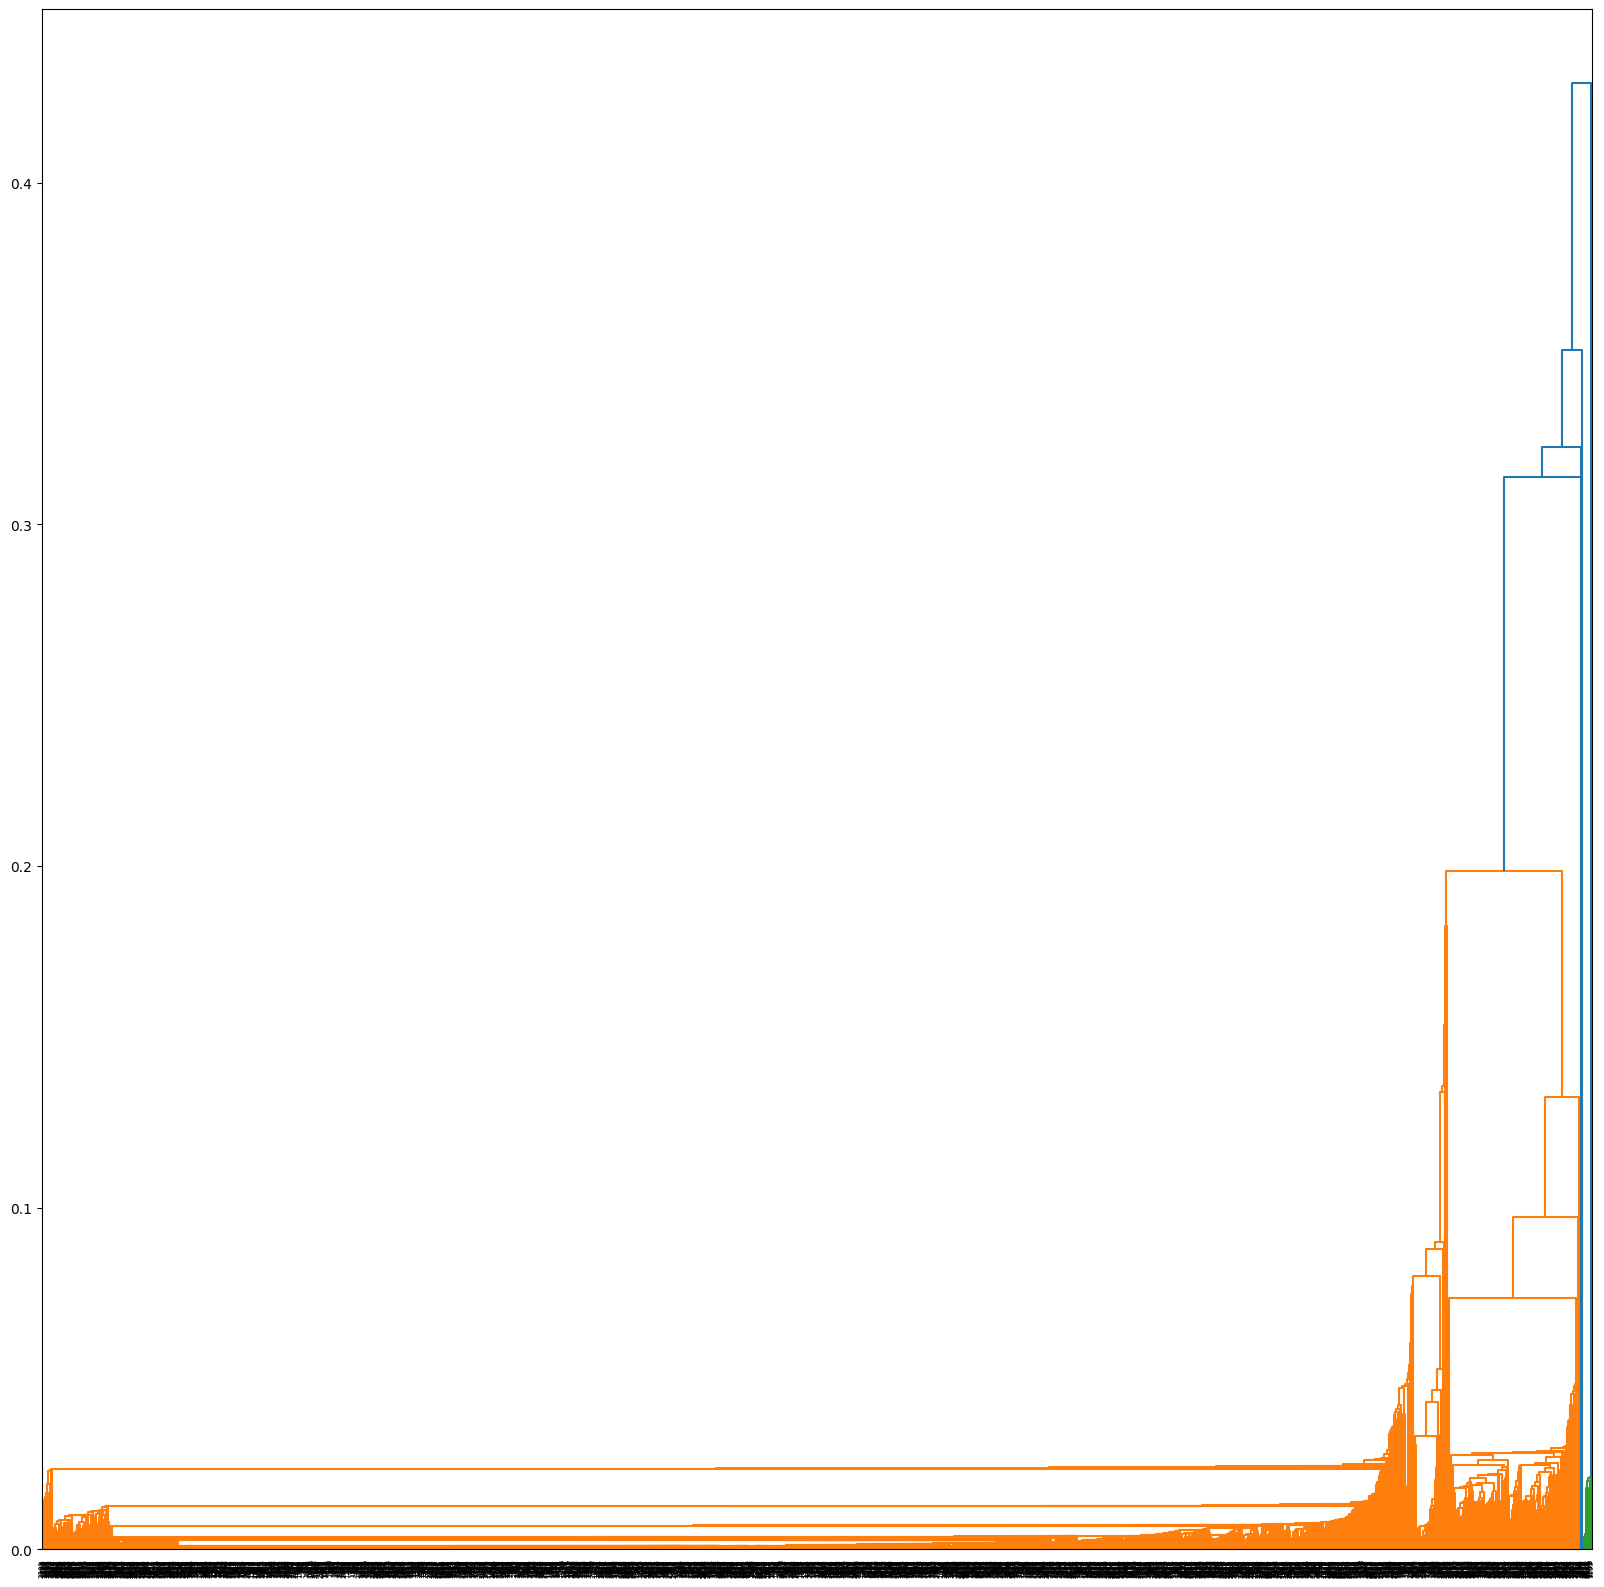

In [250]:
import scipy.cluster.hierarchy as shc

linked_mat = shc.linkage(data_pca, "single")

plt.figure(figsize=(20,20))
shc.dendrogram(linked_mat,
              orientation='top',
              distance_sort='descending',
              show_leaf_counts=True)
plt.show()

In [251]:
tps1 = time.time()
scores_pca_tree = {
    "distance_threshold": [],
    "silhouette": [],
    "calinski_harabasz": [],
    "davies_bouldin": []
}
dist = 0.01
tps1 = time.time()
while dist < 0.25:
    model_pca_tree = cluster.AgglomerativeClustering(distance_threshold = dist , \
        linkage = "single" , n_clusters = None)
    model_pca_tree = model_pca_tree.fit(data_pca)
    scores_pca_tree["distance_threshold"].append(dist)
    scores_pca_tree["silhouette"].append(metrics.silhouette_score(data_pca, model_pca_tree.labels_))
    scores_pca_tree["calinski_harabasz"].append(metrics.calinski_harabasz_score(data_pca, model_pca_tree.labels_))
    scores_pca_tree["davies_bouldin"].append(metrics.davies_bouldin_score(data_pca, model_pca_tree.labels_))
    dist += 0.01
    
tps2 = time.time()

print("runtime =", round (( tps2 - tps1) * 1000 , 2) ," ms")


runtime = 6321.34  ms


In [252]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=scores_pca_tree["distance_threshold"], y=scores_pca_tree["silhouette"],
                    mode='lines+markers',
                    name='Silhouette Score'))
fig.add_trace(go.Scatter(x=scores_pca_tree["distance_threshold"], y=scores_pca_tree["davies_bouldin"],
                    mode='lines+markers',
                    name='Davies-Bouldin Score'))
# Plot Calinski-Harabasz Score as a separate scale
fig.add_trace(go.Scatter(x=scores_pca_tree["distance_threshold"], y=scores_pca_tree["calinski_harabasz"],
                    mode='lines+markers',
                    name='Calinski-Harabasz Score',
                    yaxis='y2'))

fig.update_layout(
    title='Clustering Scores vs Distance Threshold with PCA and Single Linkage',
    xaxis_title='Distance Threshold',
    yaxis=dict(
        title='Silhouette / Davies-Bouldin Score',
        side='left'
    ),
    yaxis2=dict(
        title='Calinski-Harabasz Score',
        overlaying='y',
        side='right'
    )
)
fig.show()

In [253]:
tps1 = time.time()
model_pca_tree = cluster.AgglomerativeClustering(distance_threshold = 0.19 , \
    linkage = "single" , n_clusters = None)
model_pca_tree = model_pca_tree.fit(data_pca)
tps2 = time.time()

labels_pca_tree = model_pca_tree.labels_
print("nb clusters =", model_pca_tree.n_clusters_ ,", nb feuilles =", model_pca_tree.n_leaves_ , "runtime =", round (( tps2 - tps1) * 1000 , 2) ," ms")

nb clusters = 6 , nb feuilles = 3000 runtime = 93.43  ms


In [254]:
df_pca_tree = df.copy()
df_pca_tree['Cluster'] = labels_pca_tree
cluster_counts = df_pca_tree['Cluster'].value_counts().sort_index()
print(cluster_counts)
nb_clusters = cluster_counts.shape[0]
df_pca_tree.head(100)

# Visualisation 3D
fig = px.scatter_3d(df_reduced, x='PCA1', y='PCA2', z='PCA3',
                    color=df_pca_tree['Cluster'].astype(str),
                    hover_data=['name'],
                    title='3D PCA of Steam Games Dataset with Clusters',
                    labels={'color': 'Cluster'})
fig.show()

Cluster
0    2721
1      19
2     257
3       1
4       1
5       1
Name: count, dtype: int64


In [268]:
## Calcul des scores
scores_pca_tree = {}
scores_pca_tree['silhouette'] = metrics.silhouette_score(data_pca, labels_pca_tree)
scores_pca_tree['calinski_harabasz'] = metrics.calinski_harabasz_score(data_pca, labels_pca_tree)
scores_pca_tree['davies_bouldin'] = metrics.davies_bouldin_score(data_pca, labels_pca_tree)
print("Scores for PCA Agglomerative Clustering with single linkage:")
for score_name, score_value in scores_pca_tree.items():
    print(f"{score_name}: {score_value}")

# Tracer les scores avec les barres
fig = go.Figure()
fig.add_trace(go.Bar(x=['silhouette', 'davies_bouldin'], y=[scores_pca_tree['silhouette'], scores_pca_tree['davies_bouldin']],
                    name='PCA Agglomerative Clustering Scores'))
fig.add_trace(go.Bar(x=['calinski_harabasz'], y=[scores_pca_tree['calinski_harabasz']],
                    name='PCA Agglomerative Clustering Scores (Calinski-Harabasz)',
                    yaxis='y2'))
fig.update_layout(
    title='Clustering Scores vs Epsilon with PCA and Agglomerative (single linkage)',
    xaxis_title='Epsilon',
    yaxis=dict(
        title='Silhouette / Davies-Bouldin Score',
        side='left'
    ),
    yaxis2=dict(
        title='Calinski-Harabasz Score',
        overlaying='y',
        side='right'
    )
)
fig.show()

Scores for PCA Agglomerative Clustering with single linkage:
silhouette: 0.7344301983007563
calinski_harabasz: 1716.6812535373883
davies_bouldin: 0.3042935004026088


## DBSCAN

In [256]:
from sklearn.neighbors import NearestNeighbors
# Fonction pour tracer le k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])

    fig = px.line(x=range(1, len(distances)+1), y=distances, title=f'K-distance Graph (k={k})', labels={'x':'Points', 'y':f'{k}-th nearest neighbor distance'})
    fig.update_traces(mode='lines+markers')
    fig.show()

# Tracer k-distance graph
plot_k_distance_graph(data_pca, k=10)

In [257]:
# Essaie avec DBSCAN
tps1 = time.time()
scores_pca_dbscan = {
    "epsilon": [],
    "silhouette": [],
    "calinski_harabasz": [],
    "davies_bouldin": []
}
eps = 0.01
tps1 = time.time()
while eps < 0.40:
    model_pca_db = DBSCAN(eps=eps, min_samples=5)
    model_pca_db = model_pca_db.fit(data_pca)
    scores_pca_dbscan["epsilon"].append(eps)
    scores_pca_dbscan["silhouette"].append(metrics.silhouette_score(data_pca, model_pca_db.labels_))
    scores_pca_dbscan["calinski_harabasz"].append(metrics.calinski_harabasz_score(data_pca, model_pca_db.labels_))
    scores_pca_dbscan["davies_bouldin"].append(metrics.davies_bouldin_score(data_pca, model_pca_db.labels_))
    eps += 0.01
    
tps2 = time.time()

In [258]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=scores_pca_dbscan["epsilon"], y=scores_pca_dbscan["silhouette"],
                    mode='lines+markers',
                    name='Silhouette Score'))
fig.add_trace(go.Scatter(x=scores_pca_dbscan["epsilon"], y=scores_pca_dbscan["davies_bouldin"],
                    mode='lines+markers',
                    name='Davies-Bouldin Score'))
# Plot Calinski-Harabasz Score as a separate scale
fig.add_trace(go.Scatter(x=scores_pca_dbscan["epsilon"], y=scores_pca_dbscan["calinski_harabasz"],
                    mode='lines+markers',
                    name='Calinski-Harabasz Score',
                    yaxis='y2'))

fig.update_layout(
    title='Clustering Scores vs Epsilon with PCA and DBSCAN',
    xaxis_title='Epsilon',
    yaxis=dict(
        title='Silhouette / Davies-Bouldin Score',
        side='left'
    ),
    yaxis2=dict(
        title='Calinski-Harabasz Score',
        overlaying='y',
        side='right'
    )
)
fig.show()

In [259]:
dbscan_model = DBSCAN(eps=0.07, min_samples=5)
dbscan_model.fit(data_pca)

labels = dbscan_model.labels_

In [260]:

df_pca_db = df.copy()
df_pca_db['Cluster'] = labels
cluster_counts = df_pca_db['Cluster'].value_counts().sort_index()
print(cluster_counts)
nb_clusters = cluster_counts.shape[0]
df_pca_db.head(100)

## Plot les clusters selon les composants PCA

# Visualisation 3D
fig = px.scatter_3d(df_reduced, x='PCA1', y='PCA2', z='PCA3',
                    color=df_pca_db['Cluster'].astype(str),
                    hover_data=['name'],
                    title='3D PCA of Steam Games Dataset with Clusters',
                    labels={'color': 'Cluster'})
fig.show()

Cluster
-1      25
 0    2652
 1      19
 2      57
 3     247
Name: count, dtype: int64


In [266]:
## Calcul des scores
scores_pca_dbscan = {}
scores_pca_dbscan['silhouette'] = metrics.silhouette_score(data_pca, labels)
scores_pca_dbscan['calinski_harabasz'] = metrics.calinski_harabasz_score(data_pca, labels)
scores_pca_dbscan['davies_bouldin'] = metrics.davies_bouldin_score(data_pca, labels)
print("Scores for PCA DBSCAN Clustering:")
for score_name, score_value in scores_pca_dbscan.items():
    print(f"{score_name}: {score_value}")

# Tracer les scores avec les barres
fig = go.Figure()
fig.add_trace(go.Bar(x=['silhouette', 'davies_bouldin'], y=[scores_pca_dbscan['silhouette'], scores_pca_dbscan['davies_bouldin']],
                    name='PCA DBSCAN Clustering Scores'))
fig.add_trace(go.Bar(x=['calinski_harabasz'], y=[scores_pca_dbscan['calinski_harabasz']],
                    name='PCA DBSCAN Clustering Scores (Calinski-Harabasz)',
                    yaxis='y2'))
fig.update_layout(
    title='Clustering Scores vs Epsilon with PCA and DBSCAN',
    xaxis_title='Epsilon',
    yaxis=dict(
        title='Silhouette / Davies-Bouldin Score',
        side='left'
    ),
    yaxis2=dict(
        title='Calinski-Harabasz Score',
        overlaying='y',
        side='right'
    )
)
fig.show()

Scores for PCA DBSCAN Clustering:
silhouette: 0.7574494047199707
calinski_harabasz: 3174.485299245328
davies_bouldin: 0.9471810447204543


In [235]:
# Afficher les 10 jeux les plus recommandés par cluster
top_games = df_pca_db[df_pca_db['Cluster'] == -1].sort_values(by='recommendations', ascending=False).head(20)
print(f"Top 10 recommended games in Noise Cluster:")
print(top_games[['name', 'recommendations', 'pct_pos_total', 'num_reviews_total', 'price', 'metacritic_score', 'multi_player', 'single_player']])
print("\n")
for cluster_num in range(nb_clusters-1):
    top_games = df_pca_db[df_pca_db['Cluster'] == cluster_num].sort_values(by='metacritic_score', ascending=False).head(20)
    print(f"Top 10 recommended games in Cluster {cluster_num}:")
    print(top_games[['name', 'recommendations', 'pct_pos_total', 'num_reviews_total', 'price', 'metacritic_score', 'multi_player', 'single_player']])
    print("\n")

Top 10 recommended games in Noise Cluster:
                                                name  recommendations  \
140                     Kingdom Come: Deliverance II            56822   
433                                 Two Point Museum             1594   
1308                                  Groove Coaster             1376   
48                                             BZZZT             1206   
426                                       Everhood 2             1011   
1522                                      Interloper              231   
2258  All Walls Must Fall - A Tech-Noir Tactics Game              193   
2078                  Grimmwood - They Come at Night              191   
709                                         WildStar              126   
2728                                        Oil Rush              122   
1183                                           Redie              119   
2587                         A Valley Without Wind 2              110   
2535    